In [2]:
#!pip install easyocr pillow numpy opencv-python matplotlib pandas requests jiwer

In [5]:
import os
import re
import platform
import urllib.request
import requests

import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
import easyocr

from PIL import Image
from jiwer import wer, cer

In [6]:
reader = easyocr.Reader(
    ['de'],
    gpu=False
)

print("EasyOCR reader loaded.")

Using CPU. Note: This module is much faster with a GPU.


EasyOCR reader loaded.


C:\ProgramData\anaconda3\envs\easyOCR_env\lib\site-packages\torch\ao\nn\quantized\dynamic\modules\rnn.py:162: UserWarning: torch.quantize_per_tensor, torch.quantize_per_channel and other quantized tensor creation functions that produce tensors with dtype torch.quint8, torch.qint8, and torch.qint32 are deprecated and will be removed in a future PyTorch release. Please see https://github.com/pytorch/pytorch/issues/184982 for more information. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen\quantized\Quantizer.cpp:116.)
  w_ih = torch.quantize_per_tensor(


In [7]:
import easyocr
print("EasyOCR imported successfully")

EasyOCR imported successfully


In [8]:
def draw_bounding_boxes(image_path, min_conf=0.0):
    image = cv2.imread(image_path)

    results = reader.readtext(image_path)

    img_boxes = image.copy()

    for bbox, text, conf in results:
        if text.strip() != "" and conf >= min_conf:
            pts = np.array(bbox, dtype=np.int32)

            cv2.polylines(
                img_boxes,
                [pts],
                isClosed=True,
                color=(0, 255, 0),
                thickness=1
            )

    img_boxes = cv2.cvtColor(img_boxes, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 12))
    plt.imshow(img_boxes)
    plt.title(f"Detected Text Boxes: {image_path}")
    plt.axis("off")
    plt.show()

In [9]:
ENG_IMAGES_DIR = "../images_eng"
ENG_GOLD_DIR = "../gold_english"

C:\ProgramData\anaconda3\envs\easyOCR_env\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


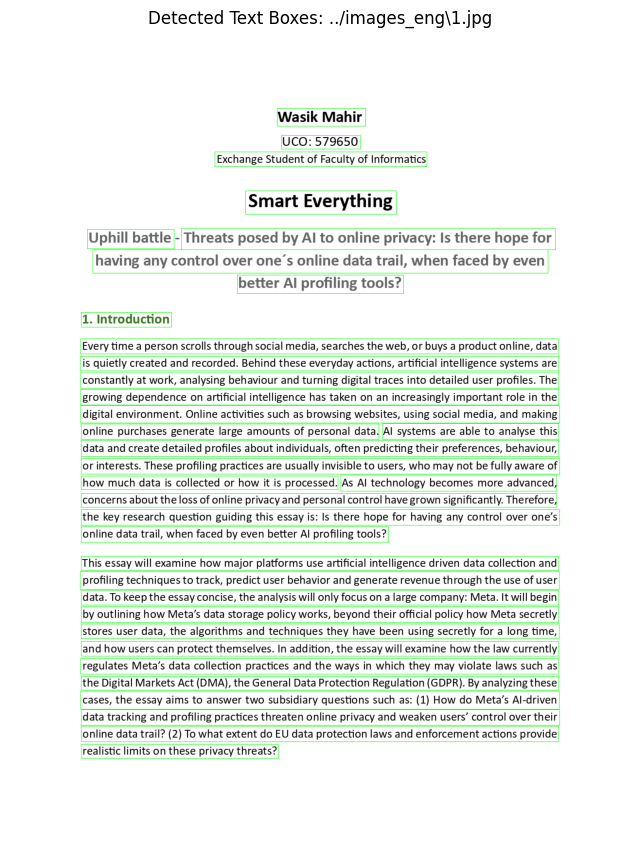

In [10]:
draw_bounding_boxes(os.path.join(ENG_IMAGES_DIR, "1.jpg"))

In [11]:
import os

output_dir_2 = "outputs/Experiment_2"
os.makedirs(output_dir_2, exist_ok=True)

In [12]:
def extract_text_easyocr(image_path, min_conf=0.0):
    results = reader.readtext(
        image_path,
        paragraph=False
    )

    filtered = []

    for bbox, text, conf in results:
        if text.strip() != "" and conf >= min_conf:
            x_min = min(point[0] for point in bbox)
            y_min = min(point[1] for point in bbox)
            y_center = sum(point[1] for point in bbox) / 4

            filtered.append({
                "text": text,
                "x": x_min,
                "y": y_min,
                "y_center": y_center
            })

    filtered = sorted(filtered, key=lambda item: item["y_center"])

    lines = []
    current_line = []
    current_y = None
    line_threshold = 18

    for item in filtered:
        if current_y is None:
            current_line = [item]
            current_y = item["y_center"]

        elif abs(item["y_center"] - current_y) <= line_threshold:
            current_line.append(item)

        else:
            current_line = sorted(current_line, key=lambda item: item["x"])
            line_text = " ".join(item["text"] for item in current_line)
            lines.append(line_text)

            current_line = [item]
            current_y = item["y_center"]

    if current_line:
        current_line = sorted(current_line, key=lambda item: item["x"])
        line_text = " ".join(item["text"] for item in current_line)
        lines.append(line_text)

    return "\n".join(lines)

In [13]:
text = extract_text_easyocr(os.path.join(ENG_IMAGES_DIR, "1.jpg"),min_conf=0.0)

print(text)

C:\ProgramData\anaconda3\envs\easyOCR_env\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Wasik Mahir
UCO: 579650
Exchange Student of Faculty of Informatics
Smart Everything
Uphill battle Threats posed by Al to online privacy: Is there hope for
having any control over one' s online data trail, when faced by even
better Al profiling tools?
1. Introduction
Every time a person scrolls through social media, searches the web, or buys a product online, data
is quietly created and recorded. Behind these everyday actions, artificial intelligence systems are
constantly at work, analysing behaviour and turning digital traces into detailed user profiles. The
growing dependence on artificial intelligence has taken on an increasingly important role in the
digital environment. Online activities such as browsing websites, using social media, and making
online purchases generate large amounts of personal data. Al systems are able to analyse this
data and create detailed profiles about individuals, often predicting their preferences; behaviour;
or interests. These profiling practices are us

In [15]:
import numpy as np
from PIL import Image


# amount = how many pixels change
# amount = 0.2 -- 20% pixel changed, amount = 0.8 -- 80% pixel changed
# salt_vs_pepper = how many are white
# salt_vs_pepper = 0.2 -- 20% white, salt_vs_pepper = 0.8 -- 80% white


def add_salt_pepper(image, amount=0.005, salt_vs_pepper=0.5):

    img = np.array(image).copy()
    h, w = img.shape[:2]

    num_pixels = int(amount * h * w)
    num_salt = int(num_pixels * salt_vs_pepper)
    num_pepper = num_pixels - num_salt

    #salt -white
    ys = np.random.randint(0, h, num_salt)
    xs = np.random.randint(0, w, num_salt)
    img[ys, xs] = 255

    #pepper -black
    ys = np.random.randint(0, h, num_pepper)
    xs = np.random.randint(0, w, num_pepper)
    img[ys, xs] = 0

    return Image.fromarray(img)

In [16]:
from PIL import Image

def zoom_img(image, zoom_scale=1.15):
    w, h = image.size
    x = w / 2
    y = h / 2

    cropped = image.crop((
        x - w / (2 * zoom_scale),
        y - h / (2 * zoom_scale),
        x + w / (2 * zoom_scale),
        y + h / (2 * zoom_scale)
    ))

    return cropped.resize((w, h), Image.BICUBIC)

def lower_res_img(image, scale=0.7):
    w, h = image.size
    low_res = image.resize((int(w * scale), int(h * scale)), Image.BICUBIC)
    return low_res.resize((w, h), Image.BICUBIC)

def add_image_distortion(image, zoom_scale=1.15, resolution_scale=0.7):
    image = zoom_img(image, zoom_scale=zoom_scale)
    image = lower_res_img(image, scale=resolution_scale)
    return image

In [17]:
import cv2
import numpy as np
from PIL import Image

def add_blur(image, kernel_size=3):
    img = np.array(image)
    blurred = cv2.GaussianBlur(img, (kernel_size, kernel_size), 0)
    return Image.fromarray(blurred)

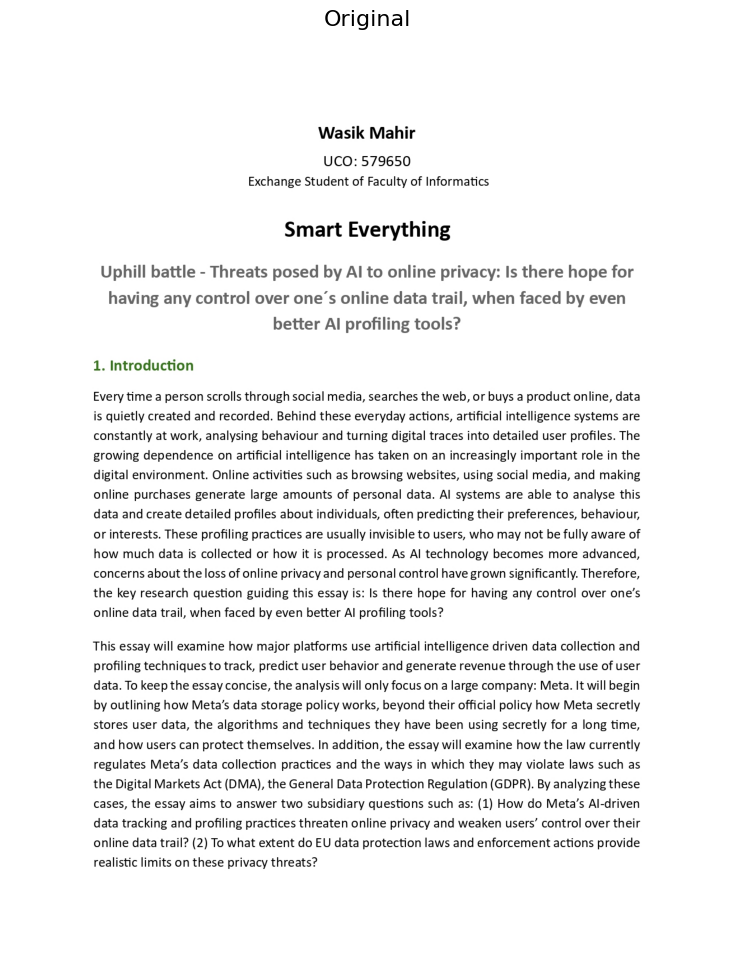

In [18]:
from PIL import Image
import matplotlib.pyplot as plt

noise_image_test = os.path.join(ENG_IMAGES_DIR,"1.jpg")

img = Image.open(noise_image_test).convert("RGB")

plt.figure(figsize=(10,12))
plt.imshow(img)
plt.title("Original", fontsize=16)
plt.axis("off")
plt.show()

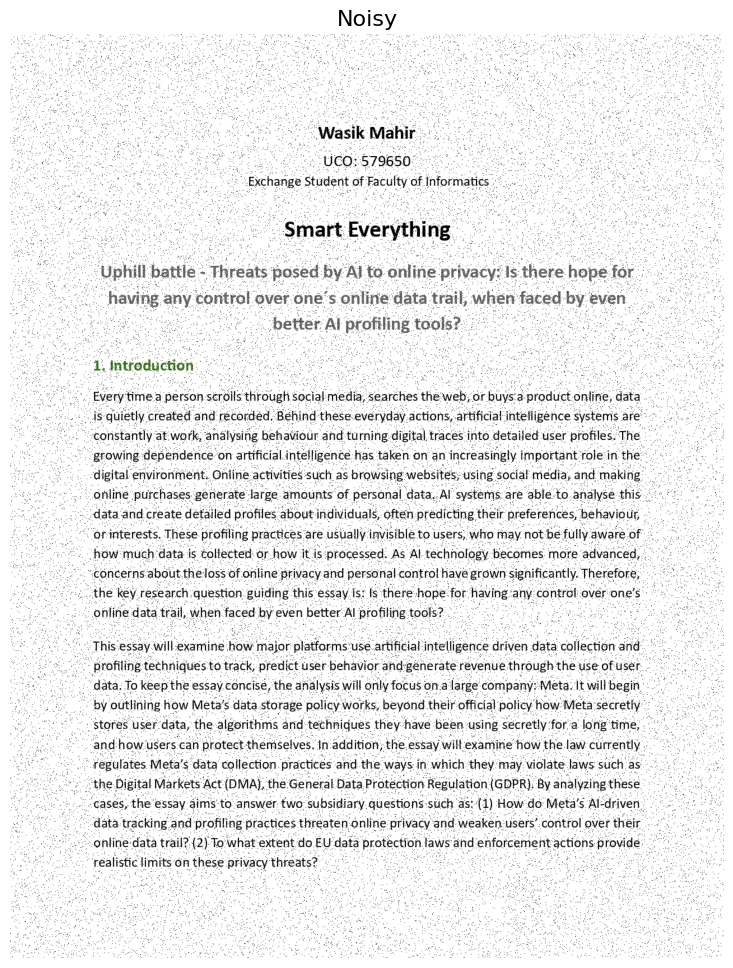

In [19]:
noisy_img = add_salt_pepper(img, amount=0.04,salt_vs_pepper=0.3)
plt.figure(figsize=(10,12))
plt.imshow(noisy_img)
plt.title("Noisy", fontsize=16)
plt.axis("off")
plt.show()

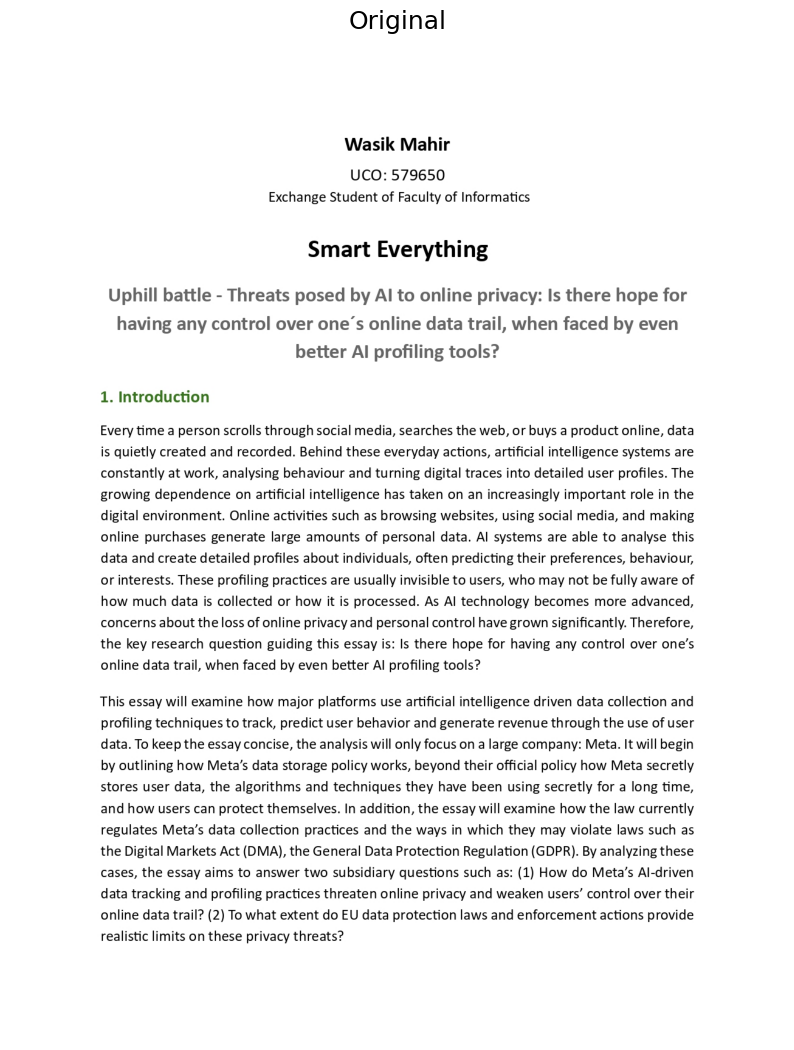

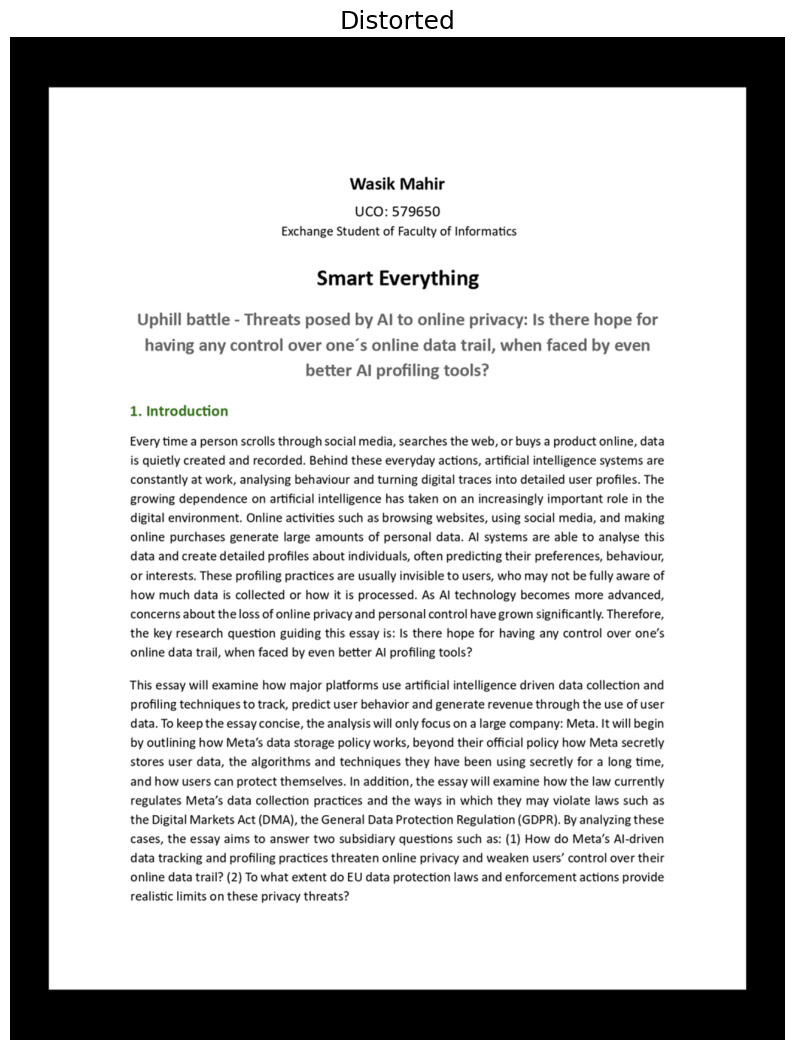

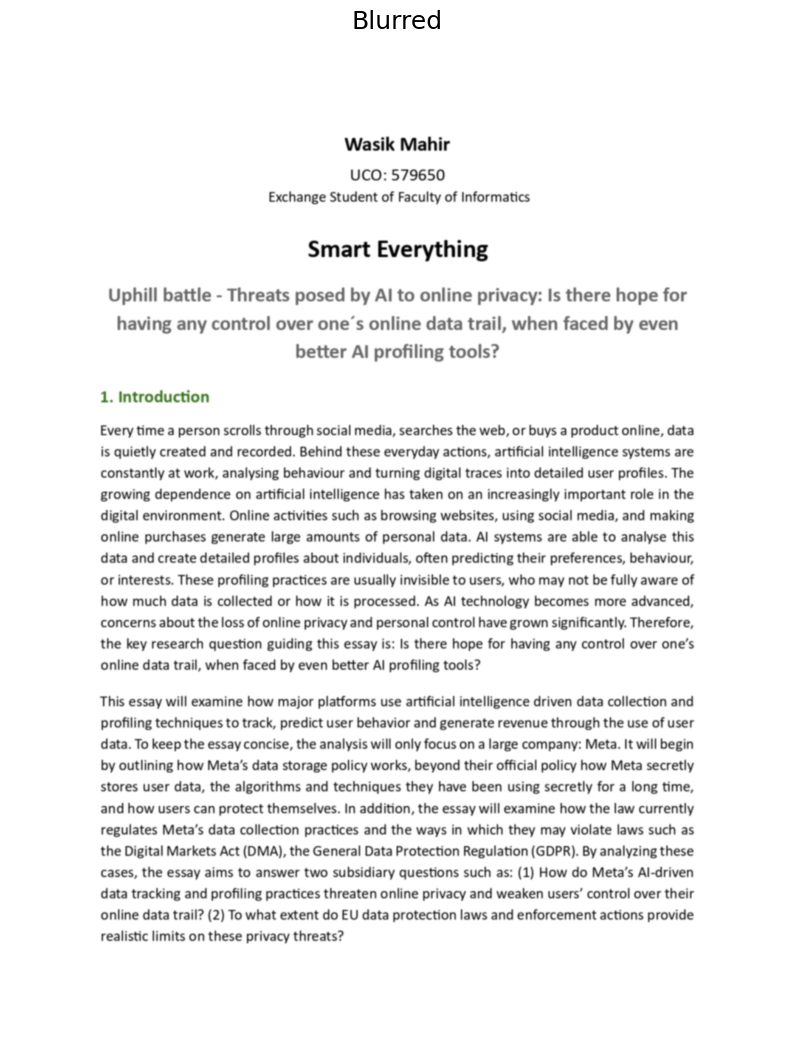

In [20]:
from PIL import Image
import matplotlib.pyplot as plt

noise_image_test2 = os.path.join(ENG_IMAGES_DIR,"1.jpg")
img1 = Image.open(noise_image_test2).convert("RGB")


distorted_img = add_image_distortion(
    img1,
    zoom_scale=0.9,
    resolution_scale=0.8
)


blurred_img = add_blur(img1, kernel_size=5)

#original
plt.figure(figsize=(10,14))
plt.imshow(img1)
plt.title("Original", fontsize=18)
plt.axis("off")
plt.show()

#distorted
plt.figure(figsize=(10,14))
plt.imshow(distorted_img)
plt.title("Distorted", fontsize=18)
plt.axis("off")
plt.show()

#blur
plt.figure(figsize=(10,14))
plt.imshow(blurred_img)
plt.title("Blurred", fontsize=18)
plt.axis("off")
plt.show()

In [21]:
def apply_all_corruptions(image,sp_amount=0.005,sp_ratio=0.5,zoom_scale=1.15,resolution_scale=0.7,
                          blur_kernel=3):
    image = add_salt_pepper(
        image,
        amount=sp_amount,
        salt_vs_pepper=sp_ratio
    )

    image = add_image_distortion(
        image,
        zoom_scale=zoom_scale,
        resolution_scale=resolution_scale
    )

    image = add_blur(
        image,
        kernel_size=blur_kernel
    )

    return image

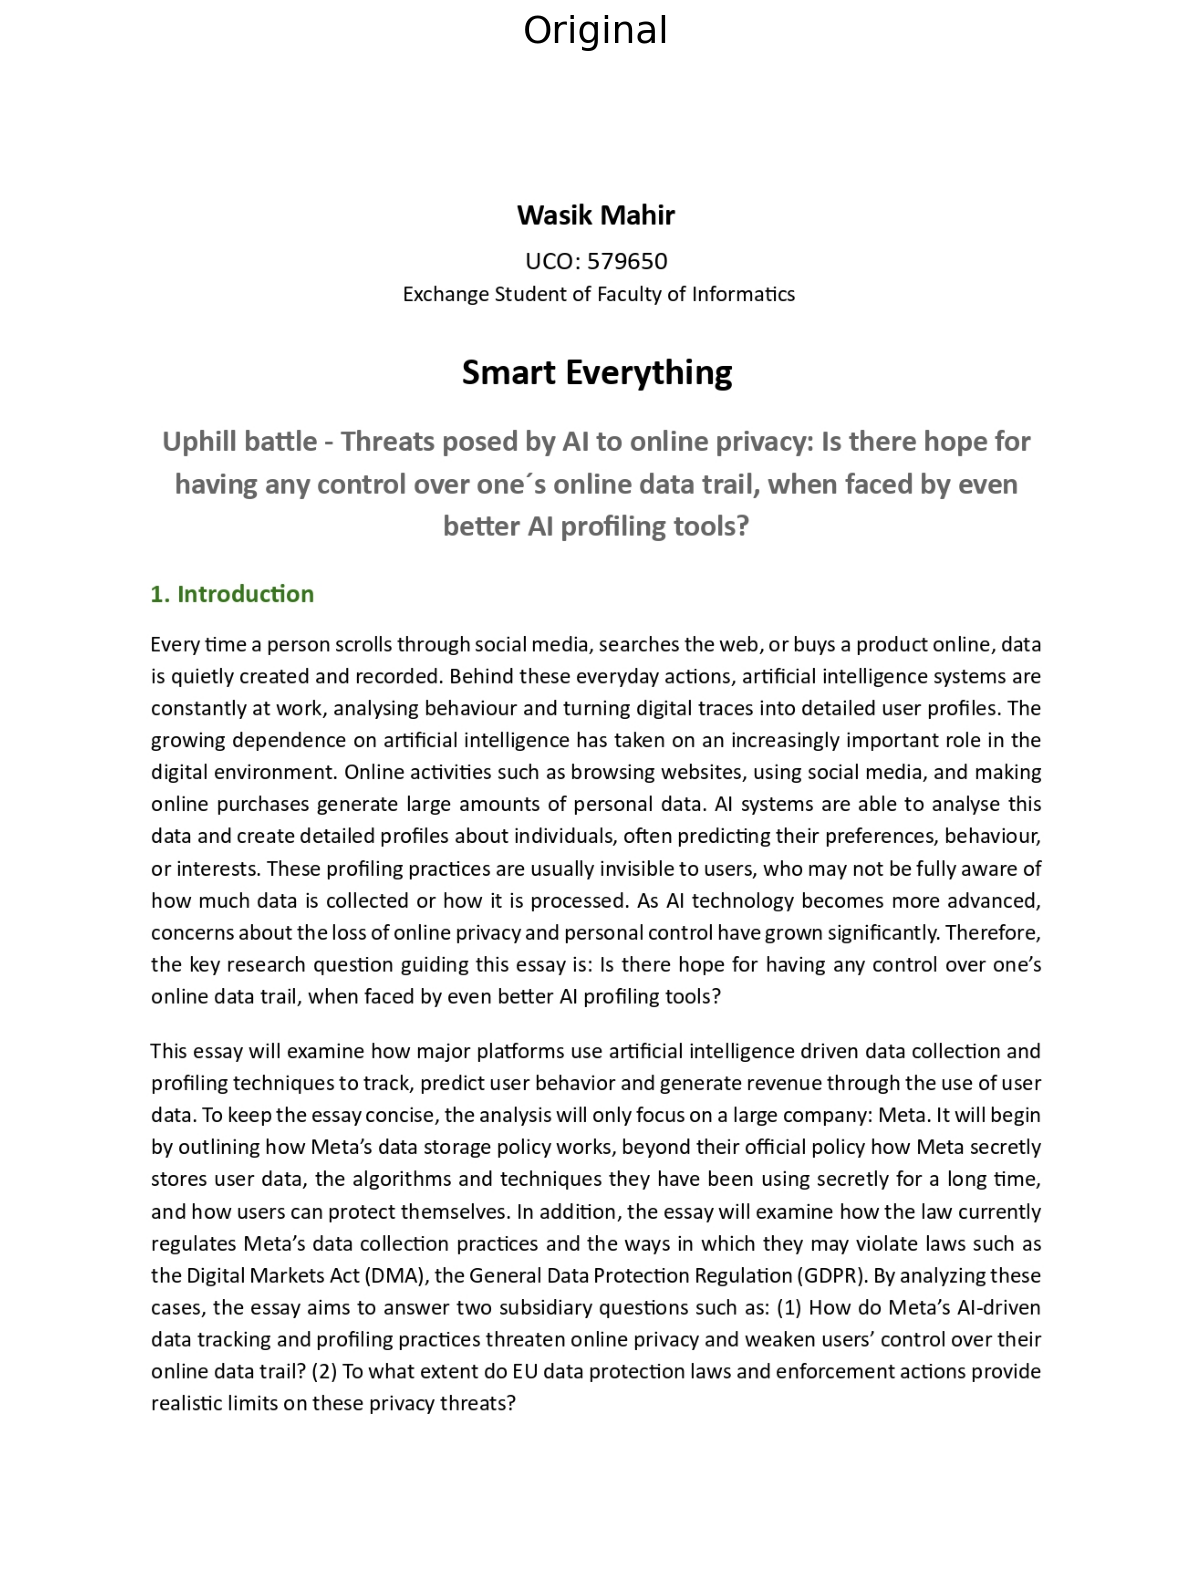

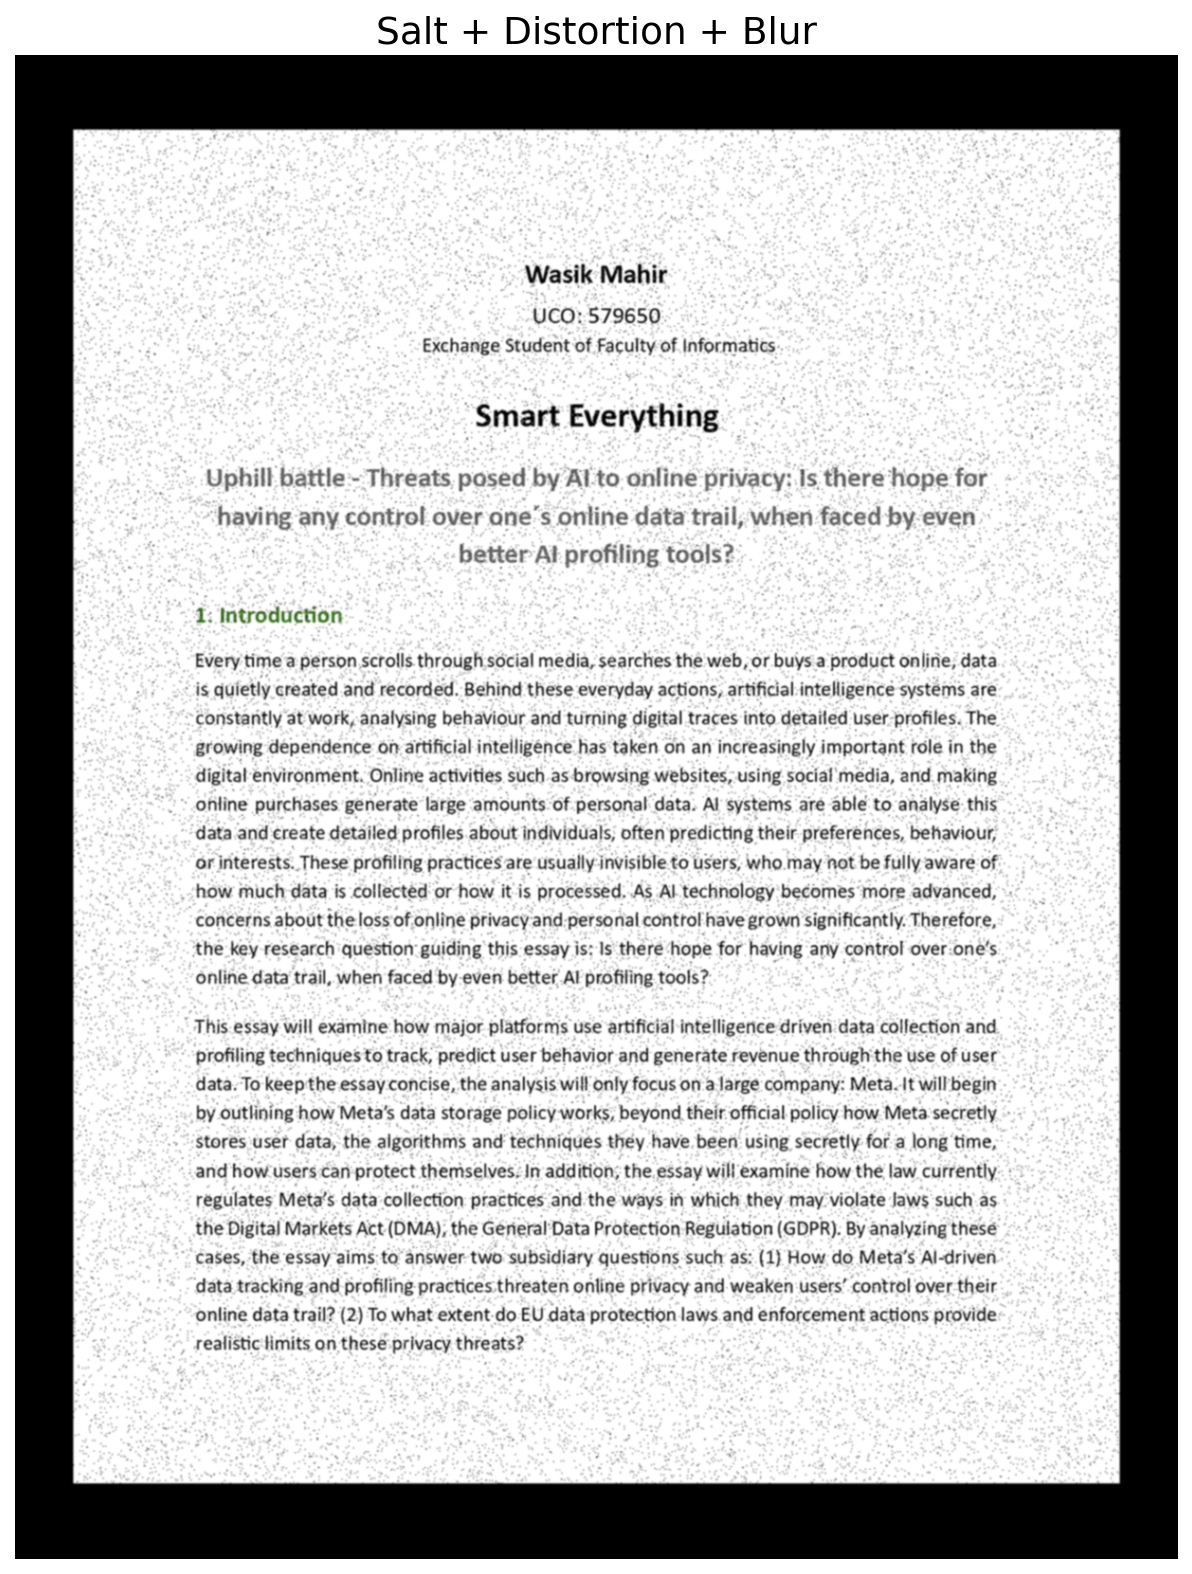

In [22]:
"""
sp_amount=0.05 ==  0.001 Very little noise, 0.05 very heavy 5% corrupted. 0.02 Heavy noise 2% corrupted,
sp_ratio=0.8 == 80% white dots, 20% black dots
zoom_scale=0.9  == Text shrinks or zoom out, 1.0 no shirnk, 1.5 zoom in
resolution_scale=1.0 == - 1.0 no quality loss, - 0.7 Noticeable blur,Thin letters begin disappearing -0.5 Heavy degradation.
blur_kernel=3, == 1 no blurr, 3 mild blurr, 5 moderate blurr, 7 strong blurr

"""
noise_image_test = os.path.join(ENG_IMAGES_DIR,"1.jpg")

img = Image.open(noise_image_test).convert("RGB")
combined_img = apply_all_corruptions(
    img,
    sp_amount=0.04,
    sp_ratio=0.4,
    zoom_scale=0.9,
    resolution_scale = 0.95,
    blur_kernel=3
)
#original
plt.figure(figsize=(10,14), dpi=150)
plt.imshow(img)
plt.title("Original", fontsize=18)
plt.axis("off")
plt.show()

#combined
plt.figure(figsize=(10,14), dpi=150)
plt.imshow(combined_img)
plt.title("Salt + Distortion + Blur", fontsize=18)
plt.axis("off")
plt.show()

In [24]:
import os
os.makedirs("corrupted_images", exist_ok=True)

In [25]:
pages = [1,2,3,4,5,6] 

In [26]:
from PIL import Image

for p in pages:
    img = Image.open(
        os.path.join(ENG_IMAGES_DIR, f"{p}.jpg")
    ).convert("RGB")

    combined_img = apply_all_corruptions(
        img,
        sp_amount=0.04,
        sp_ratio=0.4,
        zoom_scale=0.9,
        resolution_scale = 0.95,
        blur_kernel=3
    )

    combined_img.save(f"corrupted_images/{p}.jpg")

print("Done saving all corrupted images.")

Done saving all corrupted images.



Page 1


C:\ProgramData\anaconda3\envs\easyOCR_env\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


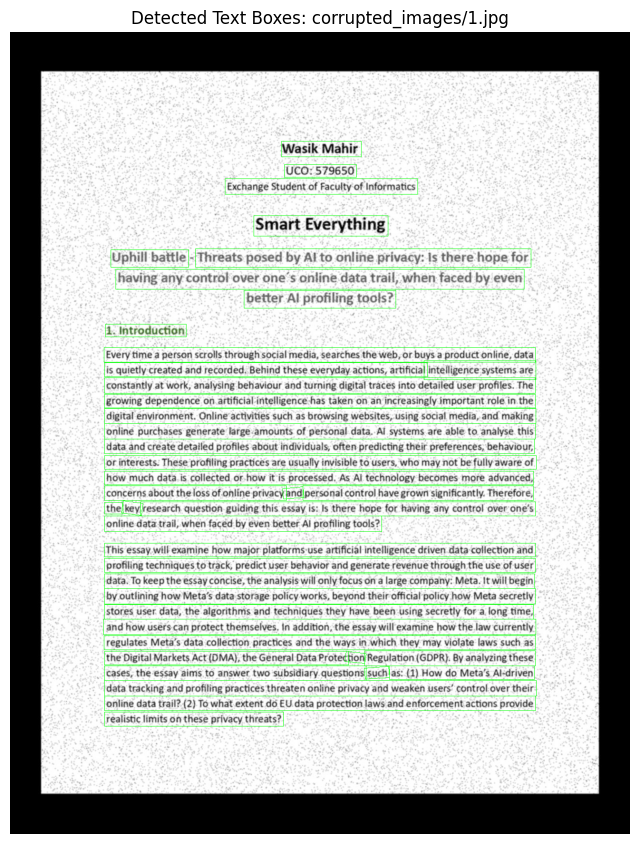

C:\ProgramData\anaconda3\envs\easyOCR_env\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Wasik Mahir
UCO: 579650
Exchange Student of Faculty of Informatics
Smart Everything
Uphill battle Threats posed by Al to online privacy: Is there hope for
having any control over one $ online data trail, when faced by even
better Al profiling tools?
1. Introduction
Every time a person scrolls through social media, searches the web, or buys a product online, data
is quietly created and recorded. Behind these everyday actions, artificial Tintelligence systems are
constantly at work, analysing behaviour and turning digital traces into detailed user profiles. The
growing dependence on artificial intelligence has taken on an increasingly important role in the
digital environment. Online activities such as browsing websites, using social media, and making
online purchases generate large amounts of personal data. Al systems are able to analyse this
data and create detalled profiles about individuals, often predicting their preferences, behaviour;
or interests. These profiling practices are us

C:\ProgramData\anaconda3\envs\easyOCR_env\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


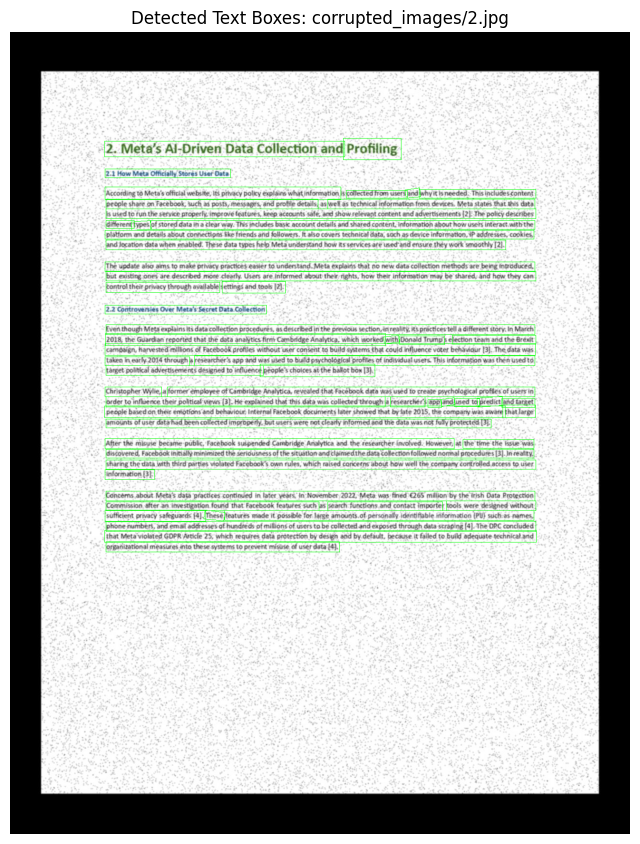

C:\ProgramData\anaconda3\envs\easyOCR_env\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


2. Meta's Al-Driven Data Collection and Profiling
2 1 Mov Meta Omncially Store: Uscr Date
According {0 Metas dficial wbslte; Its ptivacy polky @ plains what Information cdllectedhon usets @nd whyitknceded Inisinclucescontent
pecole share o facebook; such "s posts , messoges and protile Oetalls wel as technical information tromn devces Meta states that this dato
is usediorunthe servce picperlye Improveteatufes Lepp accounts sale, ond showrelevant content and aqvertisements {2| Ihe policy de cribes
ciferent types of storcd dataIn 0 clcar wayIhs includes busx account delalls and shared contenl Information abour how uscrs Interc; witblk
plottorm and deta s about connections Bke Inendsand lolloverItalsocovers technical data soch as deviceintcrmation, 'P addresses; cookies
and location data when rnabledIhese data typeshelp Meta understand how Isservkes afe (Retandensue theywok smoothly [2]
Ihi update also ams t0 make Ofivacy pracnices cosier {0 undentand Meta €xplains thal no new dota collec

C:\ProgramData\anaconda3\envs\easyOCR_env\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


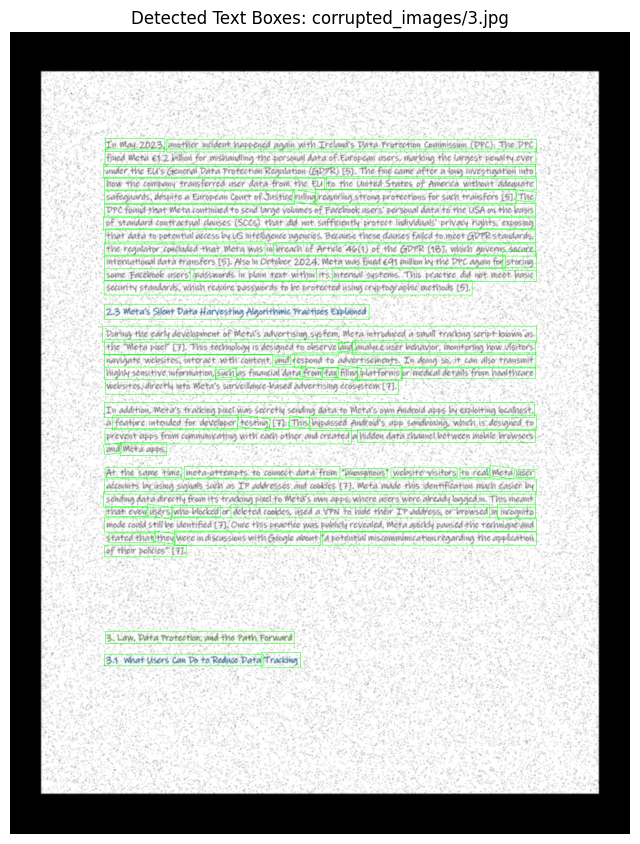

C:\ProgramData\anaconda3\envs\easyOCR_env\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Iu May-2023, avother incidcut happcved agin With Irelawjs Vata Frorcnon Commissin (VPC}: The DPC
fined #eta €1.2 Inllioii for mishawiling #nc persongl data of Europcan "sers,markig #hc largest Pewalty cver
uwcr_thc Els Gcncral Vata Protecton Regulation (GDYR) [5) Thc fnic cam after 4 b1) iwvesngatioi into
how mhe cohipany transfcrred uscr data fron the {u to the Wited Statcs f America without Gacouate
Sufeguards. Bespit6 & Europcan Court of Justice ruling rcowring strong Protcctions for swh traisfcrs [5] Thc
DPC foutid +hat Micta coutmuca +o scwd large Voluines of Fatcbook uscrs' Persoial data +o thc USA 0  #he basis
of stavdard (ontratual clauses (SCCs) thit da vot sufficicutly Protect ivdivduals' Privocy nahts, exposuug
thet data+o potantial acess b4US "tcllgcnce agcicies Bcause these dauses faicd +o mnce+ GDFR standaras;
thc regulator-concluded that Mcta was brcoch of Article 46(1) of +e GDPR [18], which Spvcr"s sccure
Intenianional data +ransfers [5] Also I Octoocr 2024,Mctawas fjn

C:\ProgramData\anaconda3\envs\easyOCR_env\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


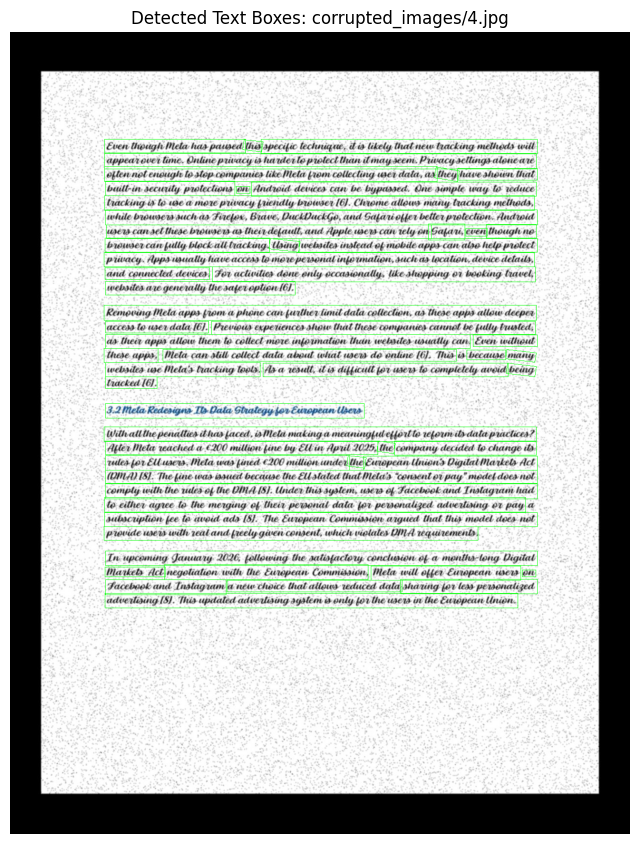

C:\ProgramData\anaconda3\envs\easyOCR_env\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Even thoughMleta has paused (hu) opecilic techuuquu , d 1 lakela that nenn tuacking mctheds wll
appeazovet tamc. Qnlinne puvacagis luudeutepztect tuuv itman kem.Puvacayactlings alonc aw
PUten net enouyh loalep compaues like Mhela {iom collecluu} wsevdala,as (h1es) Iueahoiuu {hal
builtin Mecuulty prlection Ql Audzid denices (an be bupassed, Qne Jmple way t weduce
tacking i te ica mon puvaca {uendly bwuueu [G}. Chvaomne alloue) mcuu} tackuu} mcthods
whulc bruoewsaucha filelox , Buavc; UuckUuckGe, and Salan olleubettev prtection , Audwud
we7 canoeUlluac bunue1 a {heiu delaull, and Apple tscu can wlo 0n Salau, cven (houghno
bioueezcan (ully block all tracking. Ulsag wehsites uustead 0l mobileappx can abohelp piotect
Puvacy . Apps nsually hancaccens lomowpezonal inlounalion, oucha localion, denice delails
aud conected denice Jov actintics done onls) occamionalls  like shopping 01 booking tuancl,
webodcs au genenally Uemalevoplion [61.
Rcmoning Mela apps (zm a phone can (unthcu limil dala co

C:\ProgramData\anaconda3\envs\easyOCR_env\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


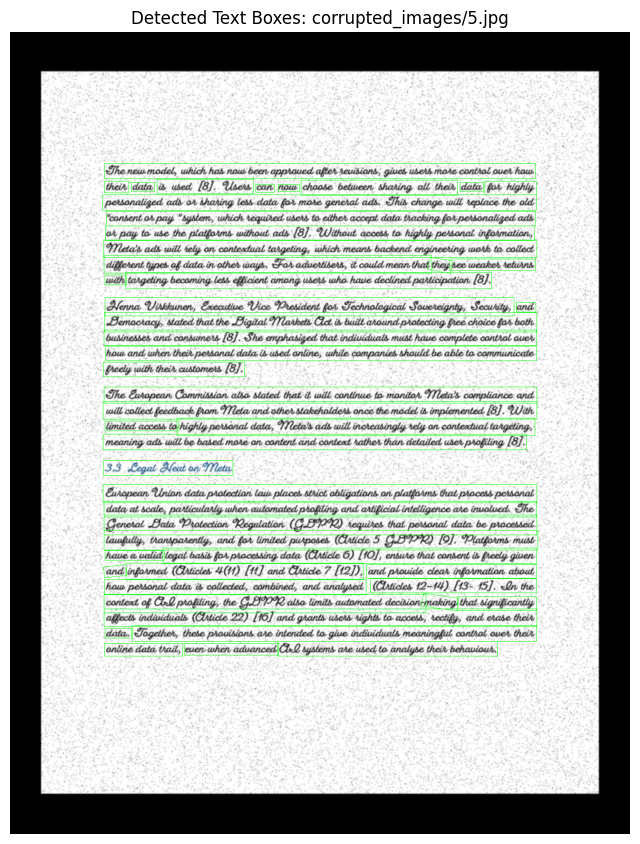

C:\ProgramData\anaconda3\envs\easyOCR_env\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Iheneumodel uhich hab now been apptoued afles Acuibions , giuch uacns mote conthol oueh how
{hcin data is used [8]. Qsens can noul choose betueen Mhaning all theit data Pon highls
petsonaliged ads 01 Shating lesa data ßox mote qencial ada. Ihis change will Aeplace the old
"consentonpa} "Mintem; which equined uschs ta eithet accept data uacking lov petsonaliped ada
01 pal to use the plalfoumb withoul ad [8] . Qithout access to hiqhl penbonal inloumation,
Ylata'e ads will nely on contendual tavqpting which meanb backend enqinceting wonk to colled
diflesent tpes 0k datain othek ways. gonaduentisen, i could meanthat they aecwcaken Aetuana
wih taqeting becoming lens elficicnt among usens who haue dedined pasticipation [8].
Benna Qinkkunen, Executiue Qice Opiesident Bon Jechnoloqical SouetciqntSecnith and
Bemochach stated that the Biqital %laskets Cd is built atound ptotecting pee choice Box both
businesses and consuneus [8]. She ephasiced Uhal indiuiduals musl hauc complete conuiol Que
hou 

C:\ProgramData\anaconda3\envs\easyOCR_env\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


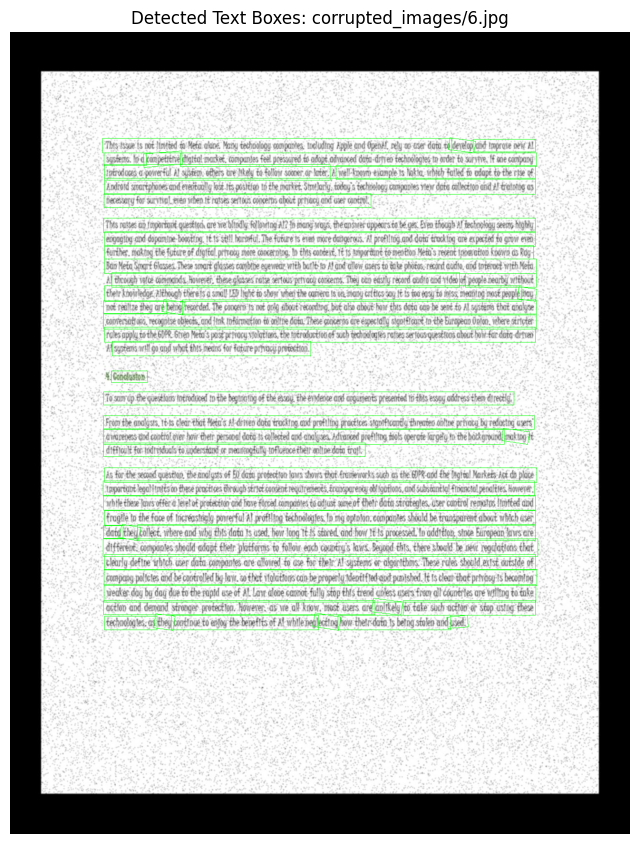

C:\ProgramData\anaconda3\envs\easyOCR_env\lib\site-packages\torch\utils\data\dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


This Issi2 Is not |lmited % Hetc alr Vonu techpoogd @mponles   Iicuding Fppe ond Opent{ Rly W user doto c delelo and Improte nw /L
Sgshe76. Ip € (petiche digital martet. (ompunles fee' pfessurd % adopt odiooced data-drtyeo tachpologtes In order to suryte K ineconpuny
Iptrddoces a powe ful Alcstem. ocjers ufe hkey to tollow sooer or lata , Vell-{nonm excmpe Is Joklc which {alled € cdopc t theris %
Aodiold saitphones apdeleitvolly bst Its Posido Ip #he partet Stmulorly: todoy ; {achnolocy cumpoples vley dcta @llecion and #! trolplog 05
Decessory for aryhal nen vben It ratses Srlli concerbs about prhacy ond wer contiol.
Thys ralszs 0o Importont quesion cre xe blindly Falowing 4/? J monj ways. theansveruppaors to teces. Eyp thoogh A #chpolocy scers higlly
ergoglng o2d dopomipe toosting !tIs still hurodu . The future !s een ore dangerais # proflltng ond datc truxcing are erpated {0 9w 0125
{urthe . moktng the {vture % dioltol prtrcag more @oncernung: J thus cobzit It Is 'mpotunt t0 mentlon 

In [27]:
for p in pages:
    print(f"\n==============================")
    print(f"Page {p}")
    print(f"==============================")

    image_path = f"corrupted_images/{p}.jpg"

    output_path = os.path.join(
        output_dir_2,
        f"page_{p}.txt"
    )

    draw_bounding_boxes(
        image_path,
        min_conf=0.0
    )
    
    output_text = extract_text_easyocr(
        image_path,
        min_conf=0.0
    )

    print(output_text)

    with open(output_path, "w", encoding="utf-8") as f:
        f.write(output_text)

    print(f"Saved: {output_path}")

In [30]:
def normalize_text(text):
    text = text.lower()
    text = text.strip()
    text = re.sub(r"\s+", " ", text)
    return text

In [31]:
results_exp2 = []

for p in pages:
    print(f"Evaluating page {p}...")

    gold_path = os.path.join(ENG_GOLD_DIR, f"{p}.txt")

    with open(gold_path, "r", encoding="utf-8") as f:
        gold_text = f.read()

    pred_path = os.path.join(output_dir_2, f"page_{p}.txt")

    with open(pred_path, "r", encoding="utf-8") as f:
        pred_text = f.read()

    gold_norm = normalize_text(gold_text)
    pred_norm = normalize_text(pred_text)

    wer_score = wer(gold_norm, pred_norm)
    cer_score = cer(gold_norm, pred_norm)

    results_exp2.append({
        "page": p,
        "WER": wer_score,
        "CER": cer_score
    })

Evaluating page 1...
Evaluating page 2...
Evaluating page 3...
Evaluating page 4...
Evaluating page 5...
Evaluating page 6...


In [32]:
print("=== Experiment 2 Results: EasyOCR ===")
df_exp2 = pd.DataFrame(results_exp2)
df_exp2

=== Experiment 2 Results: EasyOCR ===


,page,WER,CER
0,1,0.060759,0.009512
1,2,0.702564,0.170547
2,3,0.758170,0.226402
3,4,0.829885,0.293985
4,5,0.719388,0.191738
5,6,0.830303,0.284464


In [33]:
mean_wer = df_exp2["WER"].mean()
mean_cer = df_exp2["CER"].mean()

print("=== Experiment 2 Results ===")
print(f"Mean WER: {mean_wer:.4f}")
print(f"Mean CER: {mean_cer:.4f}")

=== Experiment 2 Results ===
Mean WER: 0.6502
Mean CER: 0.1961


In [34]:
import os

output_dir_result_1 = "outputs/Results"
os.makedirs(output_dir_result_1, exist_ok=True)

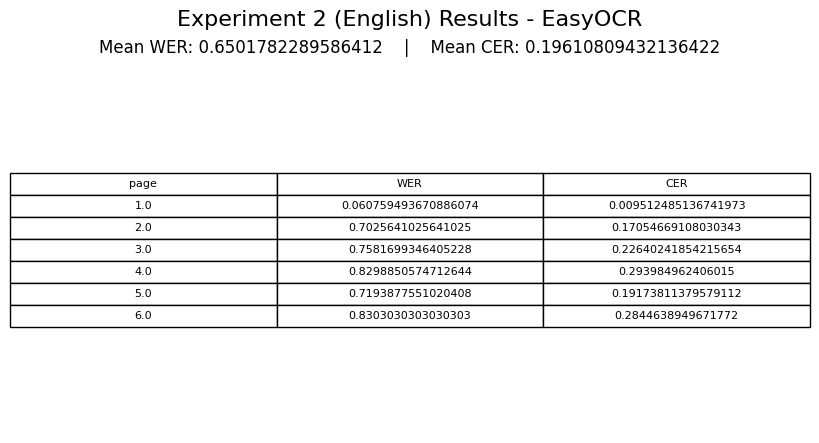

Saved: outputs/Results\experiment_2_english_easyocr_results.png


In [36]:
import os
import matplotlib.pyplot as plt

mean_wer = df_exp2["WER"].mean()
mean_cer = df_exp2["CER"].mean()

save_path = os.path.join(output_dir_result_1, "experiment_2_english_easyocr_results.png")

fig, ax = plt.subplots(figsize=(10, len(df_exp2) * 0.45 + 2))
ax.axis("off")


fig.suptitle("Experiment 2 (English) Results - EasyOCR", fontsize=16, y=0.98)

summary_text = f"Mean WER: {mean_wer}    |    Mean CER: {mean_cer}"
fig.text(0.5, 0.90, summary_text, ha="center", va="center", fontsize=12)

# Table
table = ax.table(
    cellText=df_exp2.values,
    colLabels=df_exp2.columns,
    cellLoc="center",
    colLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.3)

ax.set_position([0.1, 0.08, 0.8, 0.78])

fig.savefig(save_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
plt.close(fig)

print("Saved:", save_path)

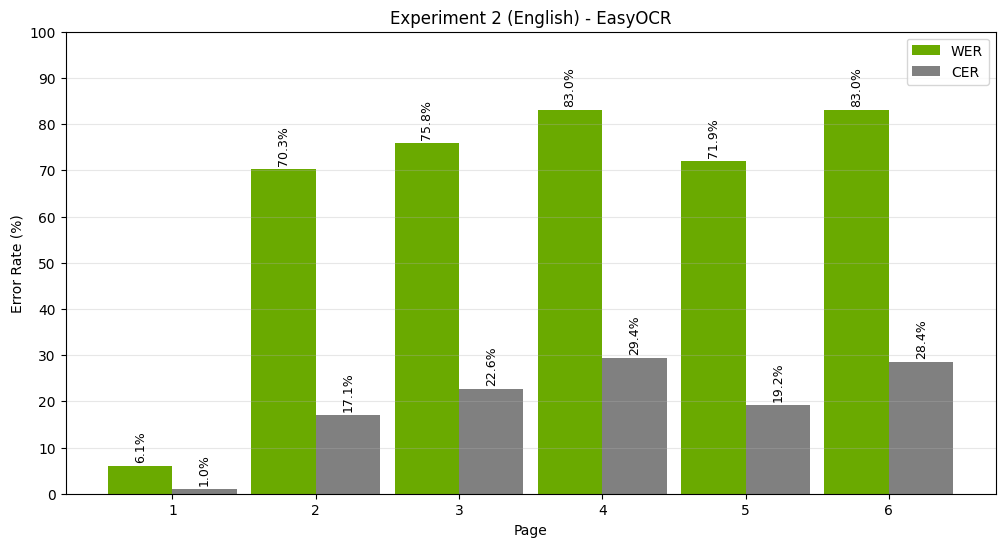

In [38]:
# with vector graphics
import numpy as np
x = np.arange(len(df_exp2))
width = 0.45

wer_pct = df_exp2["WER"] * 100
cer_pct = df_exp2["CER"] * 100

plt.figure(figsize=(12,6))

bars1 = plt.bar(x - width/2,wer_pct,width,label="WER",color="#6AAA00")
bars2 = plt.bar(x + width/2,cer_pct,width,label="CER",color="#808080")

for bar in bars1:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.8,      
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=9,
    )

for bar in bars2:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.8,
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom",
        rotation=90,
        fontsize=9
    )

plt.xticks(x, df_exp2["page"])
plt.xlabel("Page")
plt.ylabel("Error Rate (%)")
plt.title("Experiment 2 (English) - EasyOCR")

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.ylim(0, 100)
plt.yticks(np.arange(0, 101, 10))

os.makedirs(output_dir_result_1, exist_ok=True)

plt.savefig(os.path.join(output_dir_result_1,"experiment_2_english_easyocr_wer_cer_by_page.pdf"),bbox_inches="tight")

plt.show()